In [30]:
from alignparse import cs_tag
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


In [16]:
column_names = [
    "query_name", "query_length", "query_start", "query_end", "strand",
    "target_name", "target_length", "target_start", "target_end",
    "num_matches", "alignment_block_length", "mapping_quality",
    "mismatch_num","DP_score", "DP_aln_score", "ambiguous_num", "aln_type",
    "minimizers", "chaining", "best_chaining", "gap", "repetitive", "mutations","E"
]

In [17]:
paf_file = "../results/alignments/229E_tile1.paf"  
df = pd.read_csv(paf_file, sep='\t', names=column_names)


/tmp/ipykernel_49655/1966864770.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(paf_file, sep='\t', names=column_names)


In [48]:
def prase_paf_mutations(muts):
    if 'rl' in muts:
        return 'no_muts'
    
    full_muts_cs = muts.split('cs:Z:')[1]
    if full_muts_cs == None:
        return 'no_muts'
    else:
        mutations = cs_tag.cs_to_mutation_str(full_muts_cs)
    return mutations
    

In [49]:
df['full_muts'] = df['mutations'].apply(lambda x: prase_paf_mutations(x))

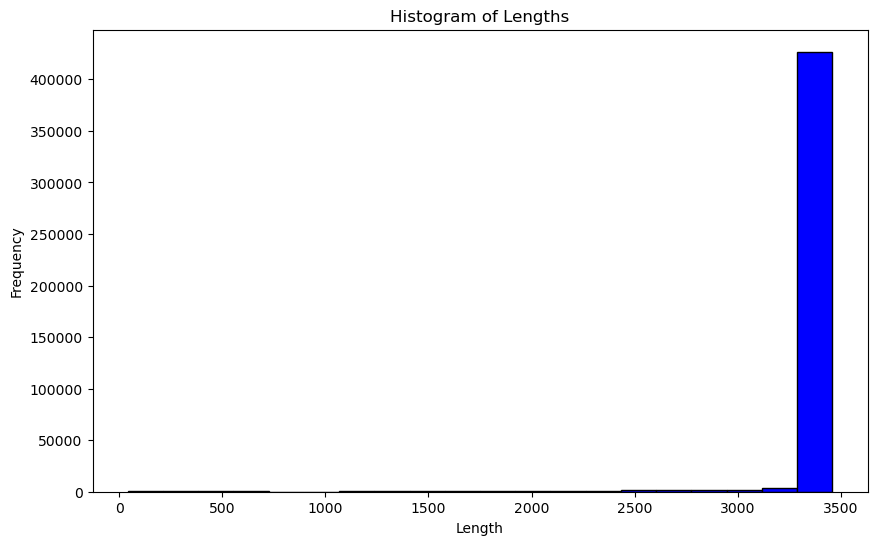

In [55]:
plt.figure(figsize=(10, 6))
plt.hist(df['num_matches'], bins=20, color='blue', edgecolor='black')
plt.title('Histogram of Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [51]:
def read_muts(mut):
    print (mut)

In [52]:
df['nat'] = df['full_muts'].apply(lambda x: read_muts(x))

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



del98to98 G123A del263to263 del694to694 del776to776 ins1484C ins2242C del2719to2719 ins3283C
G132A G133T C134G del1137to1137 del1286to1286 del1387to1387
A66C A67C G73T
G127A A129G del185to186 C189G ins266T
A184G ins933G del2497to2497 ins2645A
ins226C T247G G248A ins833C ins936CC ins1098C ins1485C ins1779C del1970to1970 ins2823C
T143C ins939G ins2394G ins2610G ins2946G
del7to7 ins29A del143to143 del157to157 ins194T ins204G del219to219 ins251G del267to268 ins270GAG ins360A T401A A402T ins433C ins530G ins734C ins842C ins882C ins887C ins960C ins974C ins1011C del1097to1097 T1199A ins2017T ins2745A del2819to2819 ins2961G ins3215C
A193C G194T C195G del277to277 del1025to1025 del1138to1138 del1174to1174 del1443to1443 del2450to2450 del3082to3082 del3284to3284
A70G A72C A262C G263T C264G
G98T G132C G133A
A66G A67C ins129G A129T
ins133A G133T A193T del195to195
ins85G del200to200 G207T T208G ins304G del2314to2314 del3007to3007 del3147to3147 del3283to3283
G81T T82A G83C G200T del1850to1850 del1919to

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [56]:
df

,query_name,query_length,query_start,query_end,strand,target_name,target_length,target_start,target_end,num_matches,...,ambiguous_num,aln_type,minimizers,chaining,best_chaining,gap,repetitive,mutations,full_muts,nat
0,m64272e_240829_202542/1/ccs,3497,0,3454,+,229E_spike,3459,1,3459,3447,...,nn:i:0,tp:A:P,cm:i:600,s1:i:3371,s2:i:0,de:f:0.0043,rl:i:0,cs:Z::218*ta*tg*tg:432-t:252-t:172+a:434+g:172...,T219A T220G T221G del654to654 del907to907 ins1...,None
1,m64272e_240829_202542/26/ccs,3488,0,3458,+,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:631,s1:i:3437,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::140*at*tg*cg:3315,A141T T142G C143G,None
2,m64272e_240829_202542/29/ccs,3482,0,3453,+,229E_spike,3459,1,3459,3450,...,nn:i:0,tp:A:P,cm:i:626,s1:i:3421,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::125-gaaa:86*ag*gt*cg:3190-c:49,del126to129 A216G G217T C218G del3409to3409,None
3,m64272e_240829_202542/45/ccs/fwd,3495,0,3458,+,229E_spike,3459,0,3459,3455,...,nn:i:0,tp:A:P,cm:i:630,s1:i:3432,s2:i:0,de:f:0.0012,rl:i:0,cs:Z::75*cg*at*cg:754-c:2626,C76G A77T C78G del833to833,None
4,m64272e_240829_202542/45/ccs/rev,3496,37,3496,-,229E_spike,3459,0,3459,3456,...,nn:i:0,tp:A:P,cm:i:632,s1:i:3440,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::147*tg*cg*tc:3309,T148G C149G T150C,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443533,m64272e_240829_202542/180554503/ccs,3504,43,3504,-,229E_spike,3459,1,3459,3458,...,nn:i:0,tp:A:P,cm:i:625,s1:i:3423,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::239+a:239+c:969+g:2011,ins240A ins479C ins1448G,None
443534,m64272e_240829_202542/180554510/ccs,2361,0,2318,+,229E_spike,3459,1133,3459,2316,...,nn:i:0,tp:A:P,cm:i:404,s1:i:2235,s2:i:0,de:f:0.0052,rl:i:0,cs:Z::37-g:14-c:46+c:14-g:208-g:194-g:98-a:3-g...,del38to38 del53to53 ins100C del114to114 del323...,None
443535,m64272e_240829_202542/180554515/ccs/fwd,3488,0,3445,+,229E_spike,3459,0,3459,3429,...,nn:i:0,tp:A:P,cm:i:542,s1:i:3185,s2:i:0,de:f:0.0118,rl:i:0,cs:Z::14-g:45*gt:76+t:6-c:70-g:61-g:14+a:42+g:...,del15to15 G61T ins138T del144to144 del215to215...,None
443536,m64272e_240829_202542/180554515/ccs/rev,3490,43,3490,-,229E_spike,3459,0,3459,3436,...,nn:i:0,tp:A:P,cm:i:551,s1:i:3243,s2:i:0,de:f:0.0092,rl:i:0,cs:Z::17-g:89+c:41-c:20*ga*gc:12-a:116-g:54+a:...,del18to18 ins108C del149to149 G170A G171C del1...,None


In [87]:
def nucleotide_to_protein(mutations, ref_seq):
    nucleotide_changes = []
    for mut in mutations.split():
        if 'ins' not in mut and 'del' not in mut:
            try:
                ref_nt = mut[0]  
                mut_nt = mut[-1]  
                pos = int(''.join(filter(str.isdigit, mut))) - 1  
                if ref_seq[pos] == ref_nt:
                    nucleotide_changes.append((pos, mut_nt))
            except ValueError:
                continue 

    mutable_seq = list(ref_seq)
    
    for pos, mut_nt in nucleotide_changes:
        mutable_seq[pos] = mut_nt
    
    mutated_seq = "".join(mutable_seq)
    
    ref_protein = Seq(ref_seq).translate()
    mutated_protein = Seq(mutated_seq).translate()
    
    protein_muts = []
    for i, (ref_aa, mut_aa) in enumerate(zip(ref_protein, mutated_protein)):
        if ref_aa != mut_aa:
            protein_muts.append(f"{ref_aa}{i+1}{mut_aa}")
    
    return ", ".join(protein_muts)

In [91]:
ref_seq = None
with open("../data/spike.fasta") as fasta_file:  
    ref_seq = str(next(SeqIO.parse(fasta_file, "fasta")).seq)
    
df['protein_muts'] = df['full_muts'].apply(lambda x: nucleotide_to_protein(x, ref_seq))


In [94]:
def parse_protein_muts(mutations):
    parsed_muts = []
    if mutations:  
        for mut in mutations.split(', '):
            wt_aa = mut[0]  
            pos = int(mut[1:-1])  
            mut_aa = mut[-1]  
            parsed_muts.append((pos, wt_aa, mut_aa))
    return parsed_muts


all_mutations = []
for muts in df['protein_muts']:
    all_mutations.extend(parse_protein_muts(muts))

mutations_df = pd.DataFrame(all_mutations, columns=['position', 'WT', 'mutation'])


grouped_df = mutations_df.groupby(['position', 'WT'])['mutation'].apply(list).reset_index()


grouped_df.rename(columns={'mutation': 'mutations_observed'}, inplace=True)


      position WT                                 mutations_observed
0            2  F  [I, I, V, I, L, I, I, I, Y, I, L, V, Y, V, Y, ...
1            3  V  [G, D, C, D, L, L, I, I, D, D, L, D, L, I, G, ...
2            4  L  [V, M, H, M, Q, M, Q, V, R, Q, R, Q, V, M, R, ...
3            5  L  [V, R, M, R, F, V, Q, Q, Q, R, P, R, R, P, M, ...
4            6  V  [W, E, G, E, E, L, G, A, G, E, G, E, G, G, M, ...
...        ... ..                                                ...
1146      1148  S  [T, Y, T, Y, T, T, Y, T, A, A, T, A, T, A, T, ...
1147      1149  S  [T, A, T, *, P, P, A, R, T, L, L, *, A, *, *, ...
1148      1150  I  [N, N, V, M, M, S, F, T, F, M, M, M, M, M, M, ...
1149      1151  R  [Q, Q, Q, Q, L, A, A, A, A, P, L, A, A, L, L, ...
1150      1152  *  [C, G, G, R, S, R, L, C, W, C, G, R, C, S, C, ...

[1151 rows x 3 columns]


In [96]:
grouped_df['muts_num'] = grouped_df['mutations_observed'].apply(lambda x: len(x))

In [97]:
grouped_df

,position,WT,mutations_observed,muts_num
0,2,F,"[I, I, V, I, L, I, I, I, Y, I, L, V, Y, V, Y, ...",129
1,3,V,"[G, D, C, D, L, L, I, I, D, D, L, D, L, I, G, ...",70
2,4,L,"[V, M, H, M, Q, M, Q, V, R, Q, R, Q, V, M, R, ...",41
3,5,L,"[V, R, M, R, F, V, Q, Q, Q, R, P, R, R, P, M, ...",29
4,6,V,"[W, E, G, E, E, L, G, A, G, E, G, E, G, G, M, ...",74
...,...,...,...,...
1146,1148,S,"[T, Y, T, Y, T, T, Y, T, A, A, T, A, T, A, T, ...",45
1147,1149,S,"[T, A, T, *, P, P, A, R, T, L, L, *, A, *, *, ...",82
1148,1150,I,"[N, N, V, M, M, S, F, T, F, M, M, M, M, M, M, ...",115
1149,1151,R,"[Q, Q, Q, Q, L, A, A, A, A, P, L, A, A, L, L, ...",97


In [101]:
df_spike = df[df['num_matches'] > 3200]

In [102]:
df_spike

,query_name,query_length,query_start,query_end,strand,target_name,target_length,target_start,target_end,num_matches,...,ambiguous_num,aln_type,minimizers,chaining,best_chaining,gap,repetitive,mutations,full_muts,protein_muts
0,m64272e_240829_202542/1/ccs,3497,0,3454,+,229E_spike,3459,1,3459,3447,...,nn:i:0,tp:A:P,cm:i:600,s1:i:3371,s2:i:0,de:f:0.0043,rl:i:0,cs:Z::218*ta*tg*tg:432-t:252-t:172+a:434+g:172...,T219A T220G T221G del654to654 del907to907 ins1...,F74G
1,m64272e_240829_202542/26/ccs,3488,0,3458,+,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:631,s1:i:3437,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::140*at*tg*cg:3315,A141T T142G C143G,
2,m64272e_240829_202542/29/ccs,3482,0,3453,+,229E_spike,3459,1,3459,3450,...,nn:i:0,tp:A:P,cm:i:626,s1:i:3421,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::125-gaaa:86*ag*gt*cg:3190-c:49,del126to129 A216G G217T C218G del3409to3409,
3,m64272e_240829_202542/45/ccs/fwd,3495,0,3458,+,229E_spike,3459,0,3459,3455,...,nn:i:0,tp:A:P,cm:i:630,s1:i:3432,s2:i:0,de:f:0.0012,rl:i:0,cs:Z::75*cg*at*cg:754-c:2626,C76G A77T C78G del833to833,H26V
4,m64272e_240829_202542/45/ccs/rev,3496,37,3496,-,229E_spike,3459,0,3459,3456,...,nn:i:0,tp:A:P,cm:i:632,s1:i:3440,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::147*tg*cg*tc:3309,T148G C149G T150C,S50G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443531,m64272e_240829_202542/180554471/ccs/fwd,3500,0,3457,+,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:629,s1:i:3429,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::242*ca:1*gc:2004-g:1208,C243A G245C del2250to2250,C81*
443532,m64272e_240829_202542/180554471/ccs/rev,3503,43,3503,-,229E_spike,3459,1,3459,3455,...,nn:i:0,tp:A:P,cm:i:626,s1:i:3416,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::39*ct:46*at:1*tc:463+c:1617+c:1289,C40T A87T T89C ins553C ins2170C,
443533,m64272e_240829_202542/180554503/ccs,3504,43,3504,-,229E_spike,3459,1,3459,3458,...,nn:i:0,tp:A:P,cm:i:625,s1:i:3423,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::239+a:239+c:969+g:2011,ins240A ins479C ins1448G,
443535,m64272e_240829_202542/180554515/ccs/fwd,3488,0,3445,+,229E_spike,3459,0,3459,3429,...,nn:i:0,tp:A:P,cm:i:542,s1:i:3185,s2:i:0,de:f:0.0118,rl:i:0,cs:Z::14-g:45*gt:76+t:6-c:70-g:61-g:14+a:42+g:...,del15to15 G61T ins138T del144to144 del215to215...,"G21C, T363N, G364R"


In [113]:
df_spike['protein_muts_num'] = df_spike['protein_muts_list'].apply(lambda x: len(x))

/tmp/ipykernel_49655/202647137.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spike['protein_muts_num'] = df_spike['protein_muts_list'].apply(lambda x: len(x))


In [109]:
df_spike['protein_muts_list']= df_spike['protein_muts'].apply(lambda x: x.split(', '))

/tmp/ipykernel_49655/1198758670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spike['protein_muts_list']= df_spike['protein_muts'].apply(lambda x: x.split(', '))


In [114]:
df_spike

,query_name,query_length,query_start,query_end,strand,target_name,target_length,target_start,target_end,num_matches,...,minimizers,chaining,best_chaining,gap,repetitive,mutations,full_muts,protein_muts,protein_muts_num,protein_muts_list
0,m64272e_240829_202542/1/ccs,3497,0,3454,+,229E_spike,3459,1,3459,3447,...,cm:i:600,s1:i:3371,s2:i:0,de:f:0.0043,rl:i:0,cs:Z::218*ta*tg*tg:432-t:252-t:172+a:434+g:172...,T219A T220G T221G del654to654 del907to907 ins1...,F74G,1,[F74G]
1,m64272e_240829_202542/26/ccs,3488,0,3458,+,229E_spike,3459,1,3459,3455,...,cm:i:631,s1:i:3437,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::140*at*tg*cg:3315,A141T T142G C143G,,1,[]
2,m64272e_240829_202542/29/ccs,3482,0,3453,+,229E_spike,3459,1,3459,3450,...,cm:i:626,s1:i:3421,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::125-gaaa:86*ag*gt*cg:3190-c:49,del126to129 A216G G217T C218G del3409to3409,,1,[]
3,m64272e_240829_202542/45/ccs/fwd,3495,0,3458,+,229E_spike,3459,0,3459,3455,...,cm:i:630,s1:i:3432,s2:i:0,de:f:0.0012,rl:i:0,cs:Z::75*cg*at*cg:754-c:2626,C76G A77T C78G del833to833,H26V,1,[H26V]
4,m64272e_240829_202542/45/ccs/rev,3496,37,3496,-,229E_spike,3459,0,3459,3456,...,cm:i:632,s1:i:3440,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::147*tg*cg*tc:3309,T148G C149G T150C,S50G,1,[S50G]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443531,m64272e_240829_202542/180554471/ccs/fwd,3500,0,3457,+,229E_spike,3459,1,3459,3455,...,cm:i:629,s1:i:3429,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::242*ca:1*gc:2004-g:1208,C243A G245C del2250to2250,C81*,1,[C81*]
443532,m64272e_240829_202542/180554471/ccs/rev,3503,43,3503,-,229E_spike,3459,1,3459,3455,...,cm:i:626,s1:i:3416,s2:i:0,de:f:0.0014,rl:i:0,cs:Z::39*ct:46*at:1*tc:463+c:1617+c:1289,C40T A87T T89C ins553C ins2170C,,1,[]
443533,m64272e_240829_202542/180554503/ccs,3504,43,3504,-,229E_spike,3459,1,3459,3458,...,cm:i:625,s1:i:3423,s2:i:0,de:f:0.0009,rl:i:0,cs:Z::239+a:239+c:969+g:2011,ins240A ins479C ins1448G,,1,[]
443535,m64272e_240829_202542/180554515/ccs/fwd,3488,0,3445,+,229E_spike,3459,0,3459,3429,...,cm:i:542,s1:i:3185,s2:i:0,de:f:0.0118,rl:i:0,cs:Z::14-g:45*gt:76+t:6-c:70-g:61-g:14+a:42+g:...,del15to15 G61T ins138T del144to144 del215to215...,"G21C, T363N, G364R",3,"[G21C, T363N, G364R]"
